# SEAMOTH v1 — Glider Performance Calculator
**Following Graver, J.G. (2005) "Underwater Gliders: Dynamics, Control and Design", Princeton University**

Implements steady-state glide equilibrium equations from Chapters 4 and 7.

## 1. Setup & imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from dataclasses import dataclass, field

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.grid': True, 'grid.alpha': 0.3, 'figure.dpi': 120,
})

## 2. Vehicle parameters
Tune these to match your build. All SI units.

In [2]:
@dataclass
class GliderParams:
    """SEAMOTH v1 vehicle parameters. All SI units."""
    m_v: float = 8.5;           V_d: float = 8.3e-3
    hull_diam: float = 0.1143;  hull_length: float = 0.700
    S_wing: float = 0.030;      chord: float = 0.071
    AR: float = 6.0;            e_oswald: float = 0.85
    Cl_alpha_2D: float = 6.2;   Cl0_2D: float = 0.15
    Cd0_wing: float = 0.025;    Cd0_hull: float = 0.11
    Cd0_appendages: float = 0.008; hull_lift_factor: float = 1.10
    m0_max: float = 0.160
    pump_flow_loaded: float = 500e-6/60; pump_power: float = 8.0
    pump_efficiency: float = 0.45
    rho: float = 1023.0;        nu: float = 0.88e-6
    g: float = 9.81;            depth_max: float = 30.0
    battery_Wh: float = 116.0;  hotel_power: float = 0.8
    sbc_power_active: float = 7.0; sbc_power_sleep: float = 0.3
    sbc_duty_cycle: float = 0.08
    A_frontal: float = field(init=False)
    wingspan: float = field(init=False)
    def __post_init__(self):
        self.A_frontal = np.pi / 4 * self.hull_diam**2
        self.wingspan = np.sqrt(self.AR * self.S_wing)

p = GliderParams()
print(f'Hull frontal area:  {p.A_frontal*1e4:.1f} cm²')
print(f'Wingspan (wings):   {p.wingspan*1e3:.0f} mm')
print(f'Semi-span:          {(p.wingspan - p.hull_diam)/2*1e3:.0f} mm per side')
print(f'Ballast fraction:   {p.m0_max/p.m_v*100:.2f}%')

Hull frontal area:  102.6 cm²
Wingspan (wings):   424 mm
Semi-span:          155 mm per side
Ballast fraction:   1.88%


## 3. Hydrodynamic coefficients (Graver §3.2.7, §4.1.2, §5.2)

In [3]:
def compute_coefficients(p, quiet=False):
    CL_alpha = p.Cl_alpha_2D * p.AR / (p.AR + 2) * p.hull_lift_factor
    CL0 = p.Cl0_2D
    CD0 = p.Cd0_hull * (p.A_frontal / p.S_wing) + p.Cd0_wing + p.Cd0_appendages
    CD_alpha = CL_alpha**2 / (np.pi * p.AR * p.e_oswald)
    q = 0.5 * p.rho * p.S_wing
    coeffs = {
        'CL_alpha': CL_alpha, 'CL0': CL0, 'CD0': CD0, 'CD_alpha': CD_alpha,
        'KD0': q*CD0, 'KD': q*CD_alpha, 'KL0': q*CL0, 'KL': q*CL_alpha,
    }
    if not quiet:
        print('=== Hydrodynamic Coefficients ===')
        print(f'  CL_alpha (total):  {CL_alpha:.3f} rad⁻¹')
        print(f'  CL0:               {CL0:.3f}')
        print(f'  CD0 (total):       {CD0:.4f}')
        print(f'  CD_alpha:          {CD_alpha:.3f} rad⁻²')
        print(f'  L/D_max (2D est):  {CL_alpha / (2*np.sqrt(CD0*CD_alpha)):.1f}')
        print(f'\n=== Graver K Parameters ===')
        for k, v in coeffs.items():
            if k.startswith('K'): print(f'  {k:4s} = {v:.3f}')
    return coeffs

c = compute_coefficients(p)

=== Hydrodynamic Coefficients ===
  CL_alpha (total):  5.115 rad⁻¹
  CL0:               0.150
  CD0 (total):       0.0706
  CD_alpha:          1.633 rad⁻²
  L/D_max (2D est):  7.5

=== Graver K Parameters ===
  KD0  = 1.084
  KD   = 25.058
  KL0  = 2.302
  KL   = 78.490


## 4. Core equilibrium functions
All functions take glide angle in **degrees** (positive = below horizontal).

In [4]:
def equilibrium_alpha(xi_deg, c):
    """Equilibrium angle of attack [rad]. Graver Eq. 4.21.
    xi_deg: glide angle in degrees (positive = downward)."""
    xi = -np.radians(abs(xi_deg))  # Graver convention: downward = negative
    KL, KD, KL0, KD0 = c['KL'], c['KD'], c['KL0'], c['KD0']
    tan_xi = np.tan(xi)
    cot_xi = 1.0 / tan_xi
    disc = 1 - 4*(KD/KL**2)*cot_xi*(KD0*cot_xi + KL0)
    if disc < 0: return np.nan
    return abs((KL/(2*KD)) * tan_xi * (-1 + np.sqrt(disc)))

def equilibrium_speed(xi_deg, alpha, m0, p, c):
    """Equilibrium glide speed [m/s]. Graver Eq. 7.4.
    xi_deg: degrees. alpha: radians. m0: excess mass [kg]."""
    xi = np.radians(abs(xi_deg))
    fb = np.sin(xi)*(c['KD0']+c['KD']*alpha**2) + np.cos(xi)*(c['KL0']+c['KL']*alpha)
    if fb <= 0 or m0 <= 0: return np.nan
    return np.sqrt(m0 * p.g / fb)

def lift_to_drag(alpha, c):
    """L/D at given alpha [rad]. Graver Eq. 4.18."""
    return (c['CL0']+c['CL_alpha']*alpha) / (c['CD0']+c['CD_alpha']*alpha**2)

# --- Verify ---
print(f"{'ξ[°]':>6} {'α[°]':>6} {'L/D':>6} {'V@80mL':>8} {'V@160mL':>8} {'Vh@160':>8}")
print('-'*52)
for xi in [10,12,15,18,20,25,30]:
    a = equilibrium_alpha(xi, c)
    if np.isnan(a): continue
    V80  = equilibrium_speed(xi, a, 0.08, p, c)
    V160 = equilibrium_speed(xi, a, 0.16, p, c)
    print(f'{xi:6} {np.degrees(a):6.1f} {lift_to_drag(a,c):6.2f} {V80:8.2f} {V160:8.2f} {V160*np.cos(np.radians(xi)):8.2f}')

  ξ[°]   α[°]    L/D   V@80mL  V@160mL   Vh@160
----------------------------------------------------
    10    3.1   5.67     0.34     0.49     0.48
    12    2.2   4.70     0.38     0.54     0.53
    15    1.3   3.73     0.43     0.61     0.59
    18    0.8   3.08     0.47     0.67     0.63
    20    0.5   2.75     0.50     0.70     0.66
    25    0.0   2.14     0.55     0.78     0.71
    30    0.3   2.51     0.52     0.74     0.64


## 5. Reynolds number analysis

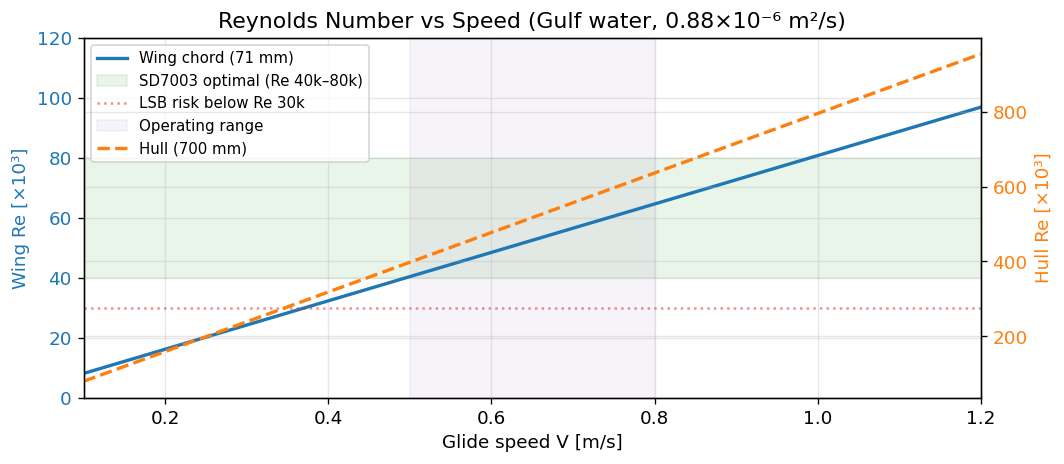

In [5]:
def reynolds_analysis(p, V_range=np.linspace(0.1, 1.2, 100)):
    Re_c = V_range * p.chord / p.nu
    Re_h = V_range * p.hull_length / p.nu
    fig, ax1 = plt.subplots(figsize=(9, 4))
    ax1.plot(V_range, Re_c/1e3, 'C0-', lw=2, label=f'Wing chord ({p.chord*1e3:.0f} mm)')
    ax1.axhspan(40, 80, alpha=0.1, color='C2', label='SD7003 optimal (Re 40k–80k)')
    ax1.axhline(30, color='C3', ls=':', alpha=0.5, label='LSB risk below Re 30k')
    ax1.axvspan(0.5, 0.8, alpha=0.08, color='C4', label='Operating range')
    ax1.set_xlabel('Glide speed V [m/s]'); ax1.set_ylabel('Wing Re [×10³]', color='C0')
    ax1.set_xlim(0.1, 1.2); ax1.set_ylim(0, 120)
    ax1.tick_params(axis='y', labelcolor='C0')
    ax2 = ax1.twinx()
    ax2.plot(V_range, Re_h/1e3, 'C1--', lw=2, label=f'Hull ({p.hull_length*1e3:.0f} mm)')
    ax2.set_ylabel('Hull Re [×10³]', color='C1')
    ax2.tick_params(axis='y', labelcolor='C1')
    h1,l1 = ax1.get_legend_handles_labels()
    h2,l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, fontsize=9, loc='upper left')
    ax1.set_title(f'Reynolds Number vs Speed (Gulf water, {p.nu*1e6:.2f}×10⁻⁶ m²/s)')
    plt.tight_layout(); plt.show()

reynolds_analysis(p)

## 6. Glide performance plots

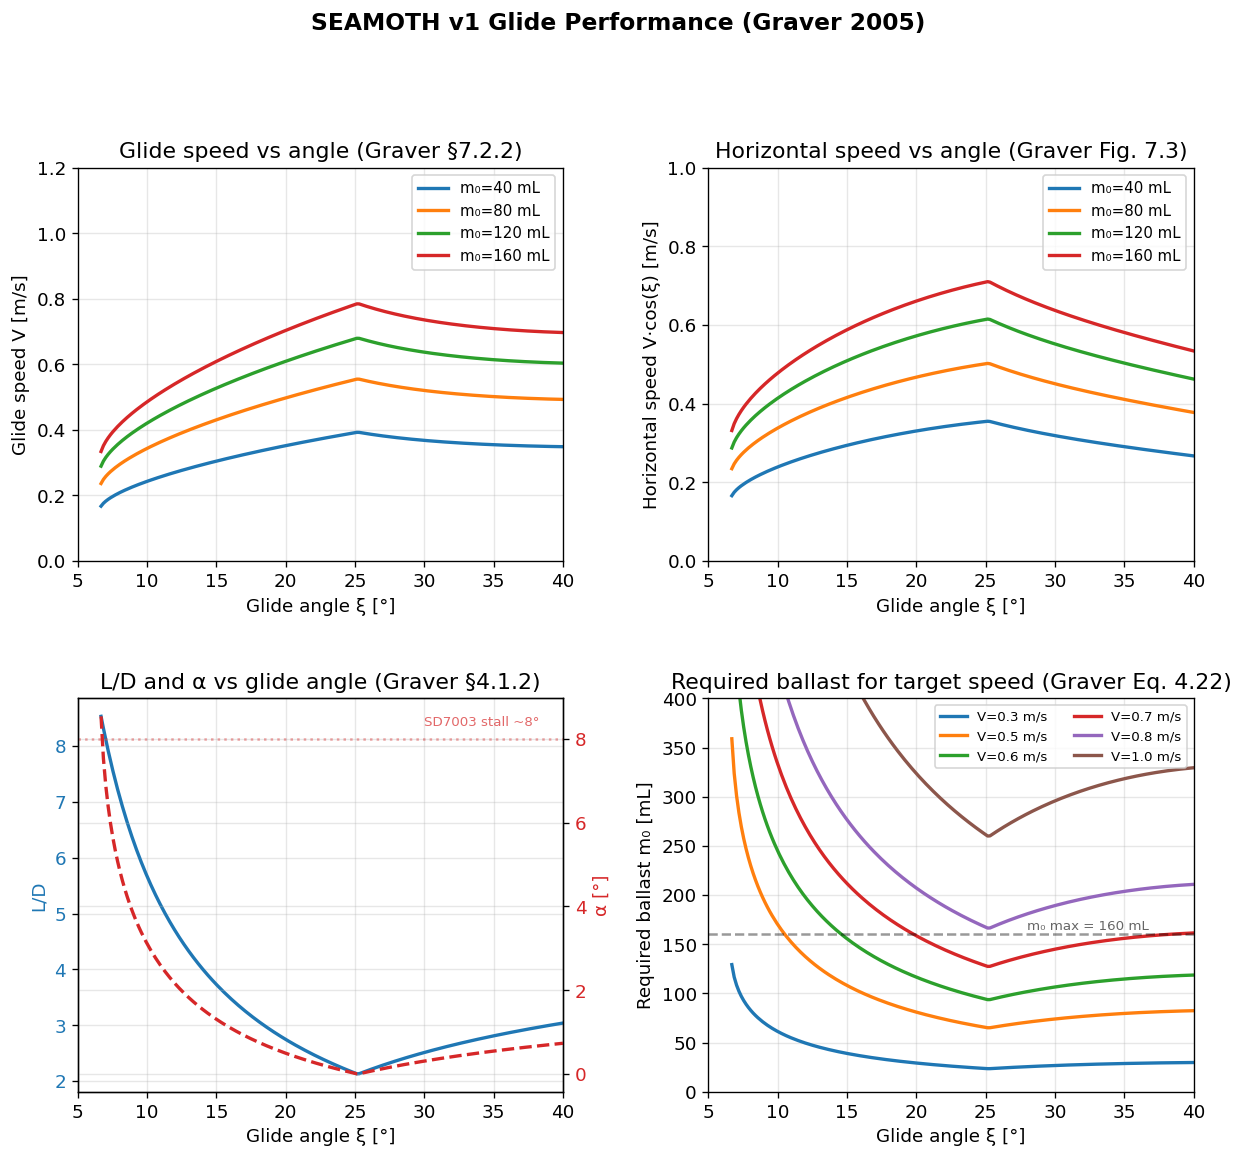

In [6]:
def plot_glide_performance(p, c, m0_values=[0.04, 0.08, 0.12, 0.16]):
    xi_degs = np.linspace(6, 40, 200)
    fig = plt.figure(figsize=(12, 10))
    gs = GridSpec(2, 2, hspace=0.35, wspace=0.3)

    ax1 = fig.add_subplot(gs[0,0])
    for m0 in m0_values:
        ax1.plot(xi_degs, [equilibrium_speed(x, equilibrium_alpha(x,c), m0, p, c) for x in xi_degs], lw=2, label=f'm₀={m0*1e3:.0f} mL')
    ax1.set(xlabel='Glide angle ξ [°]', ylabel='Glide speed V [m/s]', xlim=(5,40), ylim=(0,1.2))
    ax1.set_title('Glide speed vs angle (Graver §7.2.2)'); ax1.legend(fontsize=9)

    ax2 = fig.add_subplot(gs[0,1])
    for m0 in m0_values:
        vh = []
        for x in xi_degs:
            v = equilibrium_speed(x, equilibrium_alpha(x,c), m0, p, c)
            vh.append(v*np.cos(np.radians(x)) if not np.isnan(v) else np.nan)
        ax2.plot(xi_degs, vh, lw=2, label=f'm₀={m0*1e3:.0f} mL')
    ax2.set(xlabel='Glide angle ξ [°]', ylabel='Horizontal speed V·cos(ξ) [m/s]', xlim=(5,40), ylim=(0,1.0))
    ax2.set_title('Horizontal speed vs angle (Graver Fig. 7.3)'); ax2.legend(fontsize=9)

    ax3 = fig.add_subplot(gs[1,0])
    ld = [lift_to_drag(equilibrium_alpha(x,c), c) for x in xi_degs]
    al = [np.degrees(equilibrium_alpha(x,c)) for x in xi_degs]
    ax3.plot(xi_degs, ld, 'C0-', lw=2); ax3.set_ylabel('L/D', color='C0')
    ax3.tick_params(axis='y', labelcolor='C0'); ax3.set_xlim(5,40)
    ax3.set_title('L/D and α vs glide angle (Graver §4.1.2)'); ax3.set_xlabel('Glide angle ξ [°]')
    ax3b = ax3.twinx()
    ax3b.plot(xi_degs, al, 'C3--', lw=2); ax3b.set_ylabel('α [°]', color='C3')
    ax3b.tick_params(axis='y', labelcolor='C3')
    ax3b.axhline(8, color='C3', ls=':', alpha=0.4)
    ax3b.annotate('SD7003 stall ~8°', xy=(30,8.3), fontsize=8, color='C3', alpha=0.7)

    ax4 = fig.add_subplot(gs[1,1])
    for vt in [0.3, 0.5, 0.6, 0.7, 0.8, 1.0]:
        m0r = []
        for x in xi_degs:
            a = equilibrium_alpha(x,c); xr = np.radians(x)
            fb = np.sin(xr)*(c['KD0']+c['KD']*a**2) + np.cos(xr)*(c['KL0']+c['KL']*a)
            m0r.append(vt**2*fb/p.g*1e3 if fb>0 else np.nan)
        ax4.plot(xi_degs, m0r, lw=2, label=f'V={vt} m/s')
    ax4.axhline(160, color='k', ls='--', alpha=0.4)
    ax4.annotate('m₀ max = 160 mL', xy=(28,165), fontsize=8, alpha=0.6)
    ax4.set(xlabel='Glide angle ξ [°]', ylabel='Required ballast m₀ [mL]', xlim=(5,40), ylim=(0,400))
    ax4.set_title('Required ballast for target speed (Graver Eq. 4.22)'); ax4.legend(fontsize=8, ncol=2)

    plt.suptitle('SEAMOTH v1 Glide Performance (Graver 2005)', fontsize=14, fontweight='bold', y=1.01)
    plt.show()

plot_glide_performance(p, c)

## 7. Drag breakdown

=== Drag Breakdown at V=0.75 m/s, α=3.5° ===
  Hull parasitic       0.325 N  (45%)
  Wing profile         0.216 N  (30%)
  Wing induced         0.115 N  (16%)
  Appendages           0.069 N  (10%)
  TOTAL DRAG           0.725 N
  TOTAL LIFT           4.391 N
  L/D: 6.06   Glide angle: 9.4°


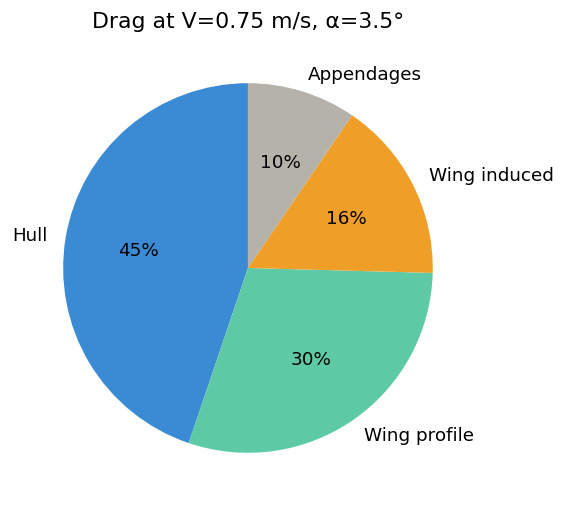

In [7]:
def drag_breakdown(p, c, V=0.75, alpha_deg=3.5):
    alpha = np.radians(alpha_deg)
    q = 0.5 * p.rho * V**2
    D_hull = q * p.Cd0_hull * p.A_frontal
    D_wp = q * p.Cd0_wing * p.S_wing
    CL = c['CL0'] + c['CL_alpha']*alpha
    D_wi = q * (CL**2/(np.pi*p.AR*p.e_oswald)) * p.S_wing
    D_app = q * p.Cd0_appendages * p.S_wing
    D_tot = D_hull+D_wp+D_wi+D_app
    L_tot = q * CL * p.S_wing * p.hull_lift_factor
    print(f'=== Drag Breakdown at V={V} m/s, α={alpha_deg}° ===')
    for name,val in [('Hull parasitic',D_hull),('Wing profile',D_wp),('Wing induced',D_wi),('Appendages',D_app)]:
        print(f'  {name:20s} {val:.3f} N  ({val/D_tot*100:.0f}%)')
    print(f'  {"TOTAL DRAG":20s} {D_tot:.3f} N')
    print(f'  {"TOTAL LIFT":20s} {L_tot:.3f} N')
    print(f'  L/D: {L_tot/D_tot:.2f}   Glide angle: {np.degrees(np.arctan(D_tot/L_tot)):.1f}°')
    fig, ax = plt.subplots(figsize=(5,5))
    ax.pie([D_hull,D_wp,D_wi,D_app], labels=['Hull','Wing profile','Wing induced','Appendages'],
           colors=['#3B8BD4','#5DCAA5','#EF9F27','#B4B2A9'], autopct='%1.0f%%', startangle=90)
    ax.set_title(f'Drag at V={V} m/s, α={alpha_deg}°'); plt.show()

drag_breakdown(p, c)

## 8. Energy & endurance (Graver §7.2.1)

In [8]:
def energy_analysis(p, c, xi_deg=15.0, m0=0.120, cycles_per_hour=6.0):
    alpha = equilibrium_alpha(xi_deg, c)
    V = equilibrium_speed(xi_deg, alpha, m0, p, c)
    Vh = V * np.cos(np.radians(xi_deg))

    dV = 2*m0/p.rho
    dP_avg = p.rho*p.g*p.depth_max/2
    E_mech = dV*dP_avg
    E_elec = E_mech/p.pump_efficiency
    t_pump = dV/p.pump_flow_loaded

    P_pump = E_elec*cycles_per_hour/3600
    P_sbc = p.sbc_power_active*p.sbc_duty_cycle + p.sbc_power_sleep*(1-p.sbc_duty_cycle)
    P_tot = p.hotel_power + P_pump + P_sbc
    t_h = p.battery_Wh/P_tot
    R = Vh*t_h*3.6

    print(f'=== Energy & Endurance ===')
    print(f'  ξ={xi_deg}°, m₀={m0*1e3:.0f} mL, V={V:.2f} m/s, Vh={Vh:.2f} m/s')
    print(f'\n  Per cycle: {dV*1e6:.0f} mL, {dP_avg/1e5:.2f} bar avg, {E_mech:.1f} J mech, {E_elec:.1f} J elec, {t_pump:.1f} s pump')
    print(f'\n  Power: hotel {p.hotel_power:.2f}W + pump {P_pump:.2f}W + SBC {P_sbc:.2f}W = {P_tot:.2f} W')
    print(f'  Endurance: {t_h:.0f} h ({t_h/24:.1f} days), {cycles_per_hour*t_h:.0f} cycles, {R:.0f} km range')
    print(f'  Energy cost: {p.battery_Wh/R:.2f} Wh/km')

energy_analysis(p, c)

=== Energy & Endurance ===
  ξ=15.0°, m₀=120 mL, V=0.53 m/s, Vh=0.51 m/s

  Per cycle: 235 mL, 1.51 bar avg, 35.3 J mech, 78.5 J elec, 28.2 s pump

  Power: hotel 0.80W + pump 0.13W + SBC 0.84W = 1.77 W
  Endurance: 66 h (2.7 days), 394 cycles, 120 km range
  Energy cost: 0.96 Wh/km


## 9. Speed vs ballast & endurance vs duty cycle

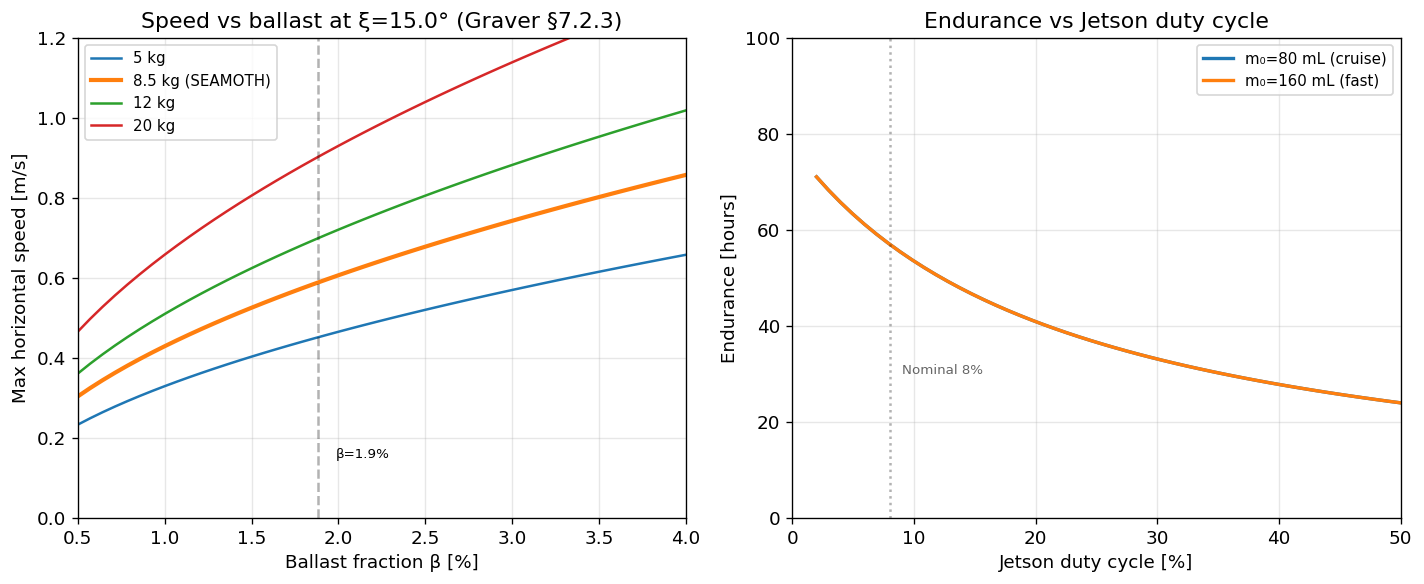

In [9]:
def plot_speed_vs_ballast(p, c):
    beta_range = np.linspace(0.005, 0.04, 50)
    xi_deg = 15.0
    alpha = equilibrium_alpha(xi_deg, c)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    for mass in [5, 8.5, 12, 20]:
        sp = [equilibrium_speed(xi_deg, alpha, b*mass, p, c)*np.cos(np.radians(xi_deg)) for b in beta_range]
        lbl = f'{mass} kg' + (' (SEAMOTH)' if mass==8.5 else '')
        ax1.plot(beta_range*100, sp, lw=2.5 if mass==8.5 else 1.5, label=lbl)
    ax1.axvline(p.m0_max/p.m_v*100, color='k', ls='--', alpha=0.3)
    ax1.annotate(f'β={p.m0_max/p.m_v*100:.1f}%', xy=(p.m0_max/p.m_v*100+0.1, 0.15), fontsize=8)
    ax1.set(xlabel='Ballast fraction β [%]', ylabel='Max horizontal speed [m/s]', xlim=(0.5,4), ylim=(0,1.2))
    ax1.set_title(f'Speed vs ballast at ξ={xi_deg}° (Graver §7.2.3)'); ax1.legend(fontsize=9)

    duty_range = np.linspace(0.02, 0.5, 50)
    for lbl, m0 in [('m₀=80 mL (cruise)', 0.08), ('m₀=160 mL (fast)', 0.16)]:
        endur = [p.battery_Wh / (p.hotel_power + p.pump_power*0.05 + p.sbc_power_active*d + p.sbc_power_sleep*(1-d)) for d in duty_range]
        ax2.plot(duty_range*100, endur, lw=2, label=lbl)
    ax2.axvline(8, color='k', ls=':', alpha=0.3)
    ax2.annotate('Nominal 8%', xy=(9,30), fontsize=8, alpha=0.6)
    ax2.set(xlabel='Jetson duty cycle [%]', ylabel='Endurance [hours]', xlim=(0,50), ylim=(0,100))
    ax2.set_title('Endurance vs Jetson duty cycle'); ax2.legend(fontsize=9)
    plt.tight_layout(); plt.show()

plot_speed_vs_ballast(p, c)

## 10. Sensitivity analysis

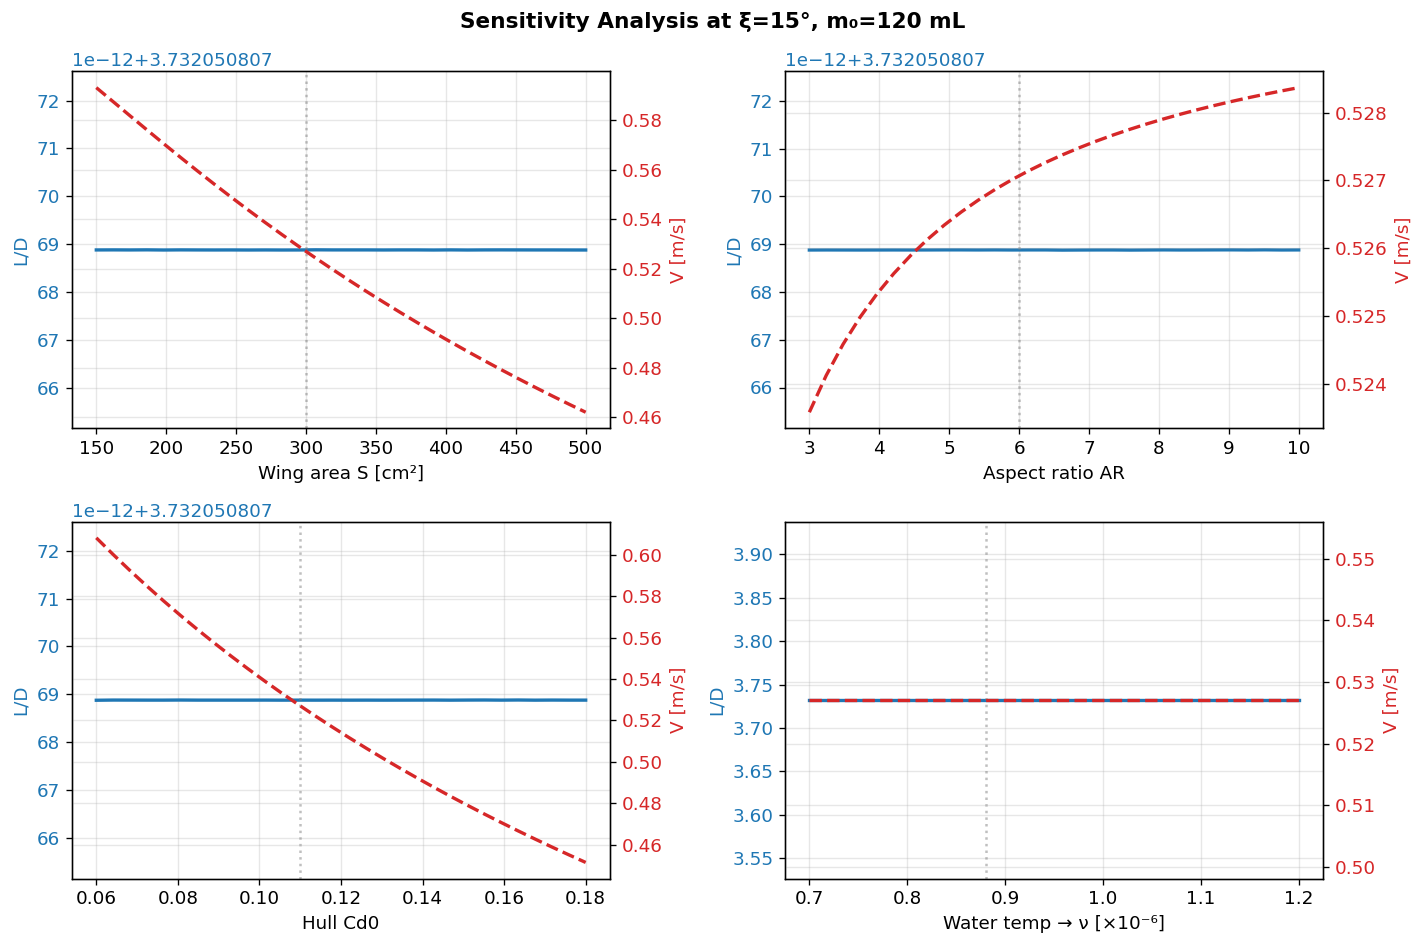

In [10]:
def sensitivity_analysis(base_params):
    xi_deg, m0 = 15.0, 0.120
    exclude = {'A_frontal', 'wingspan'}
    base_dict = {k:v for k,v in base_params.__dict__.items() if k not in exclude}
    sweeps = {
        'Wing area S [cm²]': ('S_wing', np.linspace(0.015, 0.050, 30), 1e4),
        'Aspect ratio AR': ('AR', np.linspace(3, 10, 30), 1),
        'Hull Cd0': ('Cd0_hull', np.linspace(0.06, 0.18, 30), 1),
        'Water temp → ν [×10⁻⁶]': ('nu', np.linspace(0.7e-6, 1.2e-6, 30), 1e6),
    }
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for idx, (label, (pname, vals, scale)) in enumerate(sweeps.items()):
        ld_v, sp_v = [], []
        for v in vals:
            pp = GliderParams(**{**base_dict, pname: v})
            cc = compute_coefficients(pp, quiet=True)
            a = equilibrium_alpha(xi_deg, cc)
            ld_v.append(lift_to_drag(a, cc) if not np.isnan(a) else np.nan)
            sp_v.append(equilibrium_speed(xi_deg, a, m0, pp, cc) if not np.isnan(a) else np.nan)
        ax = axes.flat[idx]
        ax.plot(vals*scale, ld_v, 'C0-', lw=2); ax.set_xlabel(label)
        ax.set_ylabel('L/D', color='C0'); ax.tick_params(axis='y', labelcolor='C0')
        ax2 = ax.twinx()
        ax2.plot(vals*scale, sp_v, 'C3--', lw=2)
        ax2.set_ylabel('V [m/s]', color='C3'); ax2.tick_params(axis='y', labelcolor='C3')
        ax.axvline(getattr(base_params, pname)*scale, color='gray', ls=':', alpha=0.5)
    plt.suptitle('Sensitivity Analysis at ξ=15°, m₀=120 mL', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

sensitivity_analysis(p)

## 11. Custom parameter sweep
Change values below and re-run to explore the design space.

In [11]:
p_custom = GliderParams(
    m_v       = 8.5,      # Vehicle mass [kg]
    S_wing    = 0.030,    # Wing area [m²]
    chord     = 0.071,    # Wing chord [m]
    AR        = 6.0,      # Aspect ratio
    m0_max    = 0.160,    # Max ballast [kg]
    hull_diam = 0.1143,   # Hull outer diameter [m]
    hull_length = 0.700,  # Hull length [m]
    rho       = 1023.0,   # Seawater density [kg/m³]
    nu        = 0.88e-6,  # Kinematic viscosity [m²/s] (Gulf, 28°C)
    battery_Wh = 116.0,   # Battery capacity [Wh]
)
c_custom = compute_coefficients(p_custom, quiet=True)

xi_deg = 25
a = equilibrium_alpha(xi_deg, c_custom)
V = equilibrium_speed(xi_deg, a, 0.120, p_custom, c_custom)
print(f'Custom parameters loaded.')
print(f'\nQuick check at ξ={xi_deg}°, m₀=120 mL:')
print(f'  α = {np.degrees(a):.1f}°, V = {V:.2f} m/s, Vh = {V*np.cos(np.radians(xi_deg)):.2f} m/s, L/D = {lift_to_drag(a, c_custom):.2f}')

Custom parameters loaded.

Quick check at ξ=25°, m₀=120 mL:
  α = 0.0°, V = 0.68 m/s, Vh = 0.61 m/s, L/D = 2.14
